# Урок 12.3. PDP, ICE и монотонные ограничения

**Интерактивная версия:** `lessons/lesson_12_3/web/index.html`

1. PDP и ICE для всех признаков; разброс центрированных ICE как мера взаимодействий.
2. Ловушка коррелированных признаков: сколько точек PDP лежит вне данных.
3. Монотонные ограничения (результаты `examples/monotone.py`) и проверка в XGBoost.

In [1]:
import json
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from gbcourse import datasets, GBRegressor
from gbcourse.explain import ice_curves, partial_dependence
from gbcourse.plotting import use_course_style

use_course_style()
X, y = datasets.friedman1(n=600, noise=1.0, seed=180, n_features=7)
model = GBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1).fit(X, y)

## 1. PDP и ICE

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


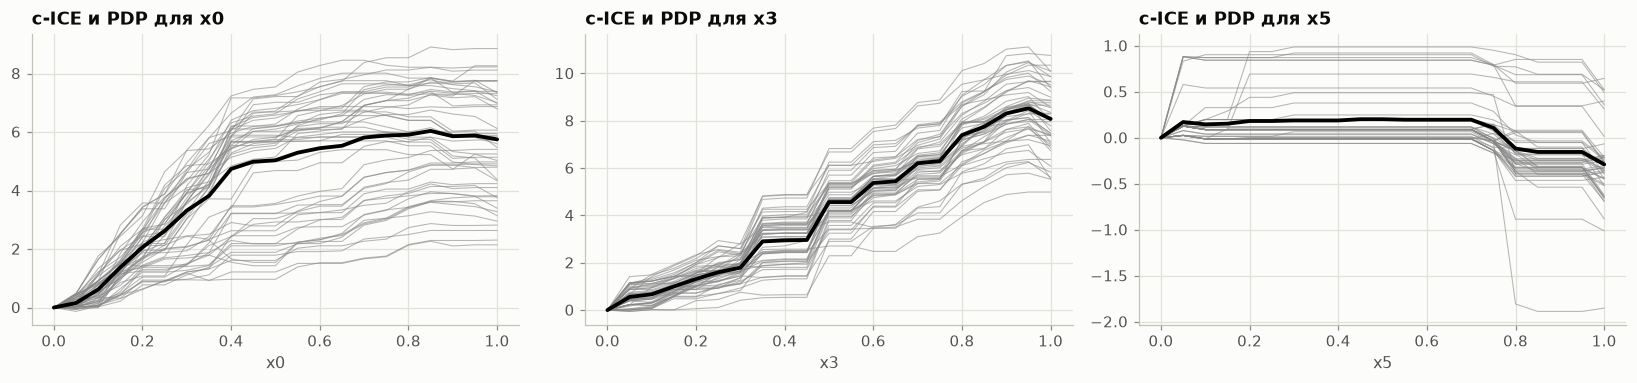

,признак,размах PDP,σ c-ICE в правом конце,σ / размах
0,x0,6.039,1.776,0.294
1,x1,6.025,1.414,0.235
2,x2,3.676,0.730,0.199
3,x3,8.531,1.368,0.160
4,x4,4.098,0.913,0.223
5,x5,0.491,0.419,0.853
6,x6,0.645,0.254,0.394


In [2]:
grid = np.linspace(0, 1, 21)
rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for j in range(7):
    _, pd_v = partial_dependence(model.predict, X[:200], j, grid=grid)
    _, ice = ice_curves(model.predict, X[:50], j, grid=grid)
    cice = ice - ice[:, :1]
    rows.append({"признак": f"x{j}", "размах PDP": pd_v.max() - pd_v.min(), "σ c-ICE в правом конце": cice[:, -1].std(),
                 "σ / размах": cice[:, -1].std() / max(pd_v.max() - pd_v.min(), 1e-9)})
    if j in (0, 3, 5):
        ax = axes[[0, 3, 5].index(j)]
        ax.plot(grid, cice.T, color="#888", lw=0.7, alpha=0.6)
        ax.plot(grid, pd_v - pd_v[0], color="k", lw=2.5)
        ax.set(title=f"c-ICE и PDP для x{j}", xlabel=f"x{j}")
plt.tight_layout()
plt.show()
pd.DataFrame(rows).round(3)

Отношение «разброс c-ICE / размах PDP» меньше всего у x3 (слагаемое 10·x3 без взаимодействий) и больше всего
у x0 среди информативных признаков (взаимодействие $\sin(\pi x_0 x_1)$). Нулевым оно не бывает: деревья глубины 3
добавляют небольшие ложные взаимодействия. У шумовых x5, x6 отношение большое, но сам размах крошечный.

## 2. Коррелированные признаки

In [3]:
rng = np.random.default_rng(0)
a = rng.uniform(0, 1, 2000)
b = a + rng.normal(0, 0.05, 2000)             # b почти равен a
yc = 3 * a + rng.normal(0, 0.3, 2000)
Xc = np.c_[a, b]
mc = GBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1).fit(Xc, yc)
g = np.linspace(0, 1, 21)
_, pd_b = partial_dependence(mc.predict, Xc[:300], 1, grid=g)
pairs = np.array([[av, gv] for av in Xc[:300, 0] for gv in g])
outside = np.mean(np.abs(pairs[:, 0] - pairs[:, 1]) > 0.15)
print(f"доля точек, где считается PDP признака b, с |a − b| > 0.15 (в данных таких {np.mean(np.abs(a - b) > 0.15):.3f}): {outside:.2f}")
print("PDP по b:", np.round(pd_b[::5], 2), "— модель опирается в основном на a, и PDP по b почти плоский,",
      "хотя b связан с y так же сильно, как a")

доля точек, где считается PDP признака b, с |a − b| > 0.15 (в данных таких 0.001): 0.73
PDP по b: [1.33 1.56 1.53 1.67 1.77] — модель опирается в основном на a, и PDP по b почти плоский, хотя b связан с y так же сильно, как a


## 3. Монотонные ограничения

In [4]:
js = (ROOT / "lessons" / "lesson_12_3" / "web" / "results.js").read_text(encoding="utf-8")
Mo = json.loads(js[js.index(".monotone = ") + len(".monotone = "): js.rindex(";\n})")])
pd.DataFrame([{"зависимость": sc["name"], "n": r["n"], "RMSE без ограничения": r["free_rmse"], "RMSE с ограничением": r["mono_rmse"],
               "шагов вниз: без / с": f"{r['free_down']} / {r['mono_down']}"} for sc in Mo["scenarios"] for r in sc["sizes"]])

,зависимость,n,RMSE без ограничения,RMSE с ограничением,шагов вниз: без / с
0,монотонна,50,0.3810,0.3474,5.0 / 0.0
1,монотонна,200,0.2692,0.2379,19.6 / 0.0
2,монотонна,1000,0.1469,0.1371,32.4 / 0.0
3,не монотонна,50,0.4142,0.4469,5.8 / 0.0
4,не монотонна,200,0.2732,0.3285,18.8 / 0.0
5,не монотонна,1000,0.1519,0.2610,35.0 / 0.0


То же ограничение в XGBoost:

In [5]:
f = lambda Z: np.log1p(3 * Z[:, 0]) + 0.5 * np.sin(2 * np.pi * Z[:, 1])
Z = np.random.default_rng(0).uniform(0, 1, (200, 2))
yz = f(Z) + np.random.default_rng(1).normal(0, 0.5, 200)
Zt = np.random.default_rng(99).uniform(0, 1, (5000, 2))
for mc_ in ("(0,0)", "(1,0)"):
    m = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, monotone_constraints=mc_).fit(Z, yz)
    line = m.predict(np.c_[np.linspace(0, 1, 101), np.full(101, 0.3)])
    print(f"XGBoost {mc_}: RMSE {np.sqrt(np.mean((f(Zt) - m.predict(Zt)) ** 2)):.3f}, шагов вниз вдоль x0: {int(np.sum(np.diff(line) < -1e-9))}")

XGBoost (0,0): RMSE 0.239, шагов вниз вдоль x0: 16
XGBoost (1,0): RMSE 0.222, шагов вниз вдоль x0: 0


## Упражнения

1. Постройте PDP признака x0 при фиксированном x1 = 0.2 и x1 = 0.9. Как это объясняет расходящиеся ICE?
2. В опыте с провалом (зависимость не монотонна) найдите, при каком числе объектов ограничение начинает вредить.

Решения: `python lessons/lesson_12_3/exercises/solutions.py`.